In [1]:
import torch

print(torch.__version__)

2.12.0+cpu


In [2]:
# ============================================
# 3.1 Install and Import Libraries
# ============================================

import sys
import subprocess

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "torch"
])

# ============================================
# 3.2 Import Required Libraries
# ============================================

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn Utilities
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# PyTorch Libraries
import torch
import torch.nn as nn
import torch.optim as optim

# Save Files
import joblib
import os

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [3]:
# ============================================
# 3.3 Check PyTorch Version
# ============================================

print(torch.__version__)

2.12.0+cpu


In [4]:
# ============================================
# 3.4 Load Dataset
# ============================================

train_df = pd.read_csv("../data/train.csv")
test_df = pd.read_csv("../data/test.csv")

print("Train Shape :", train_df.shape)
print("Test Shape :", test_df.shape)

Train Shape : (140700, 20)
Test Shape : (93800, 19)


In [5]:
# ============================================
# 3.5 Create Backup Copy
# ============================================

train = train_df.copy()
test = test_df.copy()

print("Backup Created Successfully")

Backup Created Successfully


In [6]:
# ============================================
# 3.6 Drop Unnecessary Columns
# ============================================

train.drop(columns=["id", "Name"], inplace=True)
test.drop(columns=["id", "Name"], inplace=True)

print("Columns Removed Successfully")

Columns Removed Successfully


In [7]:
# ============================================
# 3.7 Separate Numerical and Categorical Columns
# ============================================

numerical_columns = train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_columns = train.select_dtypes(
    include=["object"]
).columns.tolist()

# Remove Target Column
numerical_columns.remove("Depression")

print("Numerical Columns")
print(numerical_columns)

print("\nCategorical Columns")
print(categorical_columns)

Numerical Columns
['Age', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction', 'Work/Study Hours', 'Financial Stress']

Categorical Columns
['Gender', 'City', 'Working Professional or Student', 'Profession', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness']


In [8]:
# ============================================
# 3.8 Handle Missing Values
# ============================================

# Numerical Imputer
num_imputer = SimpleImputer(
    strategy="median"
)

train[numerical_columns] = num_imputer.fit_transform(
    train[numerical_columns]
)

test[numerical_columns] = num_imputer.transform(
    test[numerical_columns]
)

# Categorical Imputer
cat_imputer = SimpleImputer(
    strategy="most_frequent"
)

train[categorical_columns] = cat_imputer.fit_transform(
    train[categorical_columns]
)

test[categorical_columns] = cat_imputer.transform(
    test[categorical_columns]
)

print("Missing Values Handled Successfully")

Missing Values Handled Successfully


In [9]:
# ============================================
# 3.9 Encode Categorical Features
# ============================================

label_encoders = {}

for column in categorical_columns:

    # Convert to String
    train[column] = train[column].astype(str)
    test[column] = test[column].astype(str)

    # Create Encoder
    le = LabelEncoder()

    # Combine Train and Test Data
    combined_data = pd.concat(
        [train[column], test[column]],
        axis=0
    )

    # Fit Encoder
    le.fit(combined_data)

    # Transform Data
    train[column] = le.transform(
        train[column]
    )

    test[column] = le.transform(
        test[column]
    )

    # Store Encoder
    label_encoders[column] = le

print("Categorical Features Encoded Successfully")

Categorical Features Encoded Successfully


In [10]:
# ============================================
# 3.10 Feature and Target Separation
# ============================================

X = train.drop(
    "Depression",
    axis=1
)

y = train["Depression"]

# Save Original Features
X_original = X.copy()

print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Shape : (140700, 17)
Target Shape : (140700,)


In [11]:
# ============================================
# 3.11 Train Test Split
# ============================================

(
    X_train,
    X_test,
    y_train,
    y_test,
    X_train_original,
    X_test_original
) = train_test_split(

    X,
    y,
    X_original,

    test_size=0.2,

    random_state=42,

    stratify=y
)

print("X_train Shape :", X_train.shape)
print("X_test Shape :", X_test.shape)

print("y_train Shape :", y_train.shape)
print("y_test Shape :", y_test.shape)

X_train Shape : (112560, 17)
X_test Shape : (28140, 17)
y_train Shape : (112560,)
y_test Shape : (28140,)


In [12]:
# ============================================
# 3.12 Feature Scaling
# ============================================

scaler = StandardScaler()

# Fit and Transform Train Data
X_train = scaler.fit_transform(
    X_train
)

# Transform Test Data
X_test = scaler.transform(
    X_test
)

# Transform Submission Test Data
test_scaled = scaler.transform(
    test
)

print("Feature Scaling Completed")

Feature Scaling Completed


In [13]:
# ============================================
# 3.13 Convert Data to Tensor
# ============================================

X_train_tensor = torch.tensor(
    X_train,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train.values,
    dtype=torch.float32
).view(-1, 1)

y_test_tensor = torch.tensor(
    y_test.values,
    dtype=torch.float32
).view(-1, 1)

print("Tensor Conversion Completed")

Tensor Conversion Completed


In [14]:
# ============================================
# 3.14 Build Deep Learning Model
# ============================================

class DepressionModel(nn.Module):

    def __init__(self):

        super(DepressionModel, self).__init__()

        self.network = nn.Sequential(

            nn.Linear(17, 128),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(128, 64),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(64, 1)
        )

    def forward(self, x):

        return self.network(x)

# Create Model
model = DepressionModel()

print(model)

DepressionModel(
  (network): Sequential(
    (0): Linear(in_features=17, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)


In [15]:
# ============================================
# 3.15 Loss Function and Optimizer
# ============================================

# Better than BCELoss + Sigmoid
criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss and Optimizer Ready")

Loss and Optimizer Ready


In [16]:
# ============================================
# 3.16 Train Model
# ============================================

epochs = 100

loss_history = []

for epoch in range(epochs):

    model.train()

    # Forward Pass
    outputs = model(
        X_train_tensor
    )

    # Calculate Loss
    loss = criterion(
        outputs,
        y_train_tensor
    )

    # Backpropagation
    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    # Store Loss
    loss_history.append(
        loss.item()
    )

    # Print Loss
    if (epoch + 1) % 5 == 0:

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Loss: {loss.item():.4f}"
        )

print("Model Training Completed")

Epoch [5/100] Loss: 0.6477
Epoch [10/100] Loss: 0.5659
Epoch [15/100] Loss: 0.4972
Epoch [20/100] Loss: 0.4336
Epoch [25/100] Loss: 0.3744
Epoch [30/100] Loss: 0.3220
Epoch [35/100] Loss: 0.2794
Epoch [40/100] Loss: 0.2486
Epoch [45/100] Loss: 0.2271
Epoch [50/100] Loss: 0.2124
Epoch [55/100] Loss: 0.2022
Epoch [60/100] Loss: 0.1957
Epoch [65/100] Loss: 0.1910
Epoch [70/100] Loss: 0.1876
Epoch [75/100] Loss: 0.1836
Epoch [80/100] Loss: 0.1809
Epoch [85/100] Loss: 0.1789
Epoch [90/100] Loss: 0.1774
Epoch [95/100] Loss: 0.1767
Epoch [100/100] Loss: 0.1755
Model Training Completed


In [17]:
# ============================================
# 3.17 Model Evaluation
# ============================================

model.eval()

with torch.no_grad():

    logits = model(
        X_test_tensor
    )

    probabilities = torch.sigmoid(
        logits
    )

    predicted = (
        probabilities >= 0.5
    ).float()

# Convert to NumPy
y_pred = predicted.numpy()

y_true = y_test_tensor.numpy()

# Metrics
accuracy = accuracy_score(
    y_true,
    y_pred
)

precision = precision_score(
    y_true,
    y_pred
)

recall = recall_score(
    y_true,
    y_pred
)

f1 = f1_score(
    y_true,
    y_pred
)

print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1 Score :", f1)

Accuracy : 0.935820895522388
Precision : 0.8315620613595348
Recall : 0.8110698220222962
F1 Score : 0.8211881188118811


In [18]:
# ============================================
# 3.18 Classification Report
# ============================================

print(
    classification_report(
        y_true,
        y_pred
    )
)

              precision    recall  f1-score   support

         0.0       0.96      0.96      0.96     23027
         1.0       0.83      0.81      0.82      5113

    accuracy                           0.94     28140
   macro avg       0.89      0.89      0.89     28140
weighted avg       0.94      0.94      0.94     28140



In [19]:
# ============================================
# 3.19 Bias Evaluation
# ============================================

evaluation_df = pd.DataFrame()

evaluation_df["Actual"] = y_test.values

evaluation_df["Predicted"] = y_pred.flatten()

# Add Demographic Features
evaluation_df["Gender"] = X_test_original["Gender"]

evaluation_df["Age"] = X_test_original["Age"]

# --------------------------------------------
# Gender Wise Accuracy
# --------------------------------------------

print("Gender Wise Accuracy")

gender_accuracy = evaluation_df.groupby(
    "Gender"
).apply(
    lambda x: accuracy_score(
        x["Actual"],
        x["Predicted"]
    )
)

print(gender_accuracy)

# --------------------------------------------
# Age Group Accuracy
# --------------------------------------------

evaluation_df["Age_Group"] = pd.cut(

    evaluation_df["Age"],

    bins=[0, 25, 45, 100],

    labels=[
        "Young",
        "Adult",
        "Senior"
    ]
)

print("\nAge Group Wise Accuracy")

age_accuracy = evaluation_df.groupby(
    "Age_Group"
).apply(
    lambda x: accuracy_score(
        x["Actual"],
        x["Predicted"]
    )
)

print(age_accuracy)

print("\nBias Evaluation Completed")

Gender Wise Accuracy
Gender
0.0    0.941064
1.0    0.933204
dtype: float64

Age Group Wise Accuracy
Age_Group
Young     0.939331
Adult     0.934365
Senior    0.938272
dtype: float64

Bias Evaluation Completed


In [20]:
# ============================================
# 3.20 Create Models Folder
# ============================================

os.makedirs(
    "../models",
    exist_ok=True
)

print("Models Folder Created Successfully")

Models Folder Created Successfully


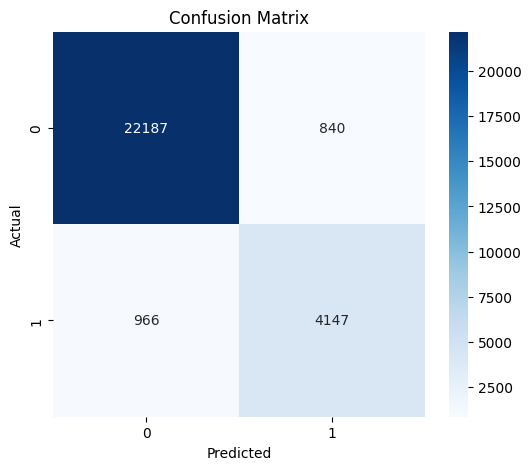

In [21]:
# ============================================
# 3.21 Confusion Matrix
# ============================================

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

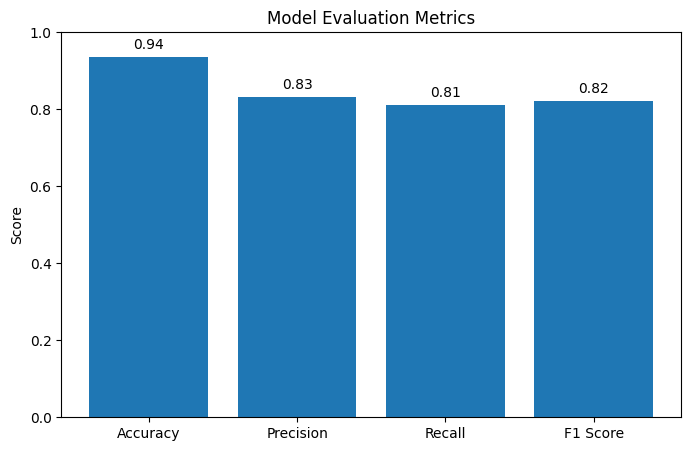

In [22]:
# ============================================
# 3.22 Accuracy, Precision, Recall, F1 Graph
# ============================================

metrics = {

    "Accuracy": accuracy,

    "Precision": precision,

    "Recall": recall,

    "F1 Score": f1
}

plt.figure(figsize=(8,5))

plt.bar(
    metrics.keys(),
    metrics.values()
)

plt.ylim(0,1)

plt.title("Model Evaluation Metrics")

plt.ylabel("Score")

for i, value in enumerate(metrics.values()):

    plt.text(
        i,
        value + 0.02,
        f"{value:.2f}",
        ha="center"
    )

plt.show()

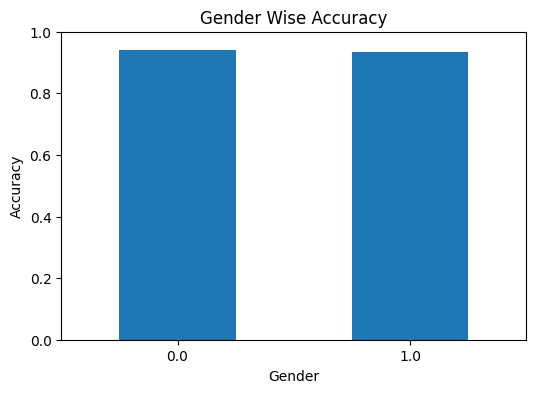

In [23]:
# ============================================
# 3.23 Gender Bias Graph
# ============================================

gender_accuracy.plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Gender Wise Accuracy")

plt.ylabel("Accuracy")

plt.ylim(0,1)

plt.xticks(rotation=0)

plt.show()

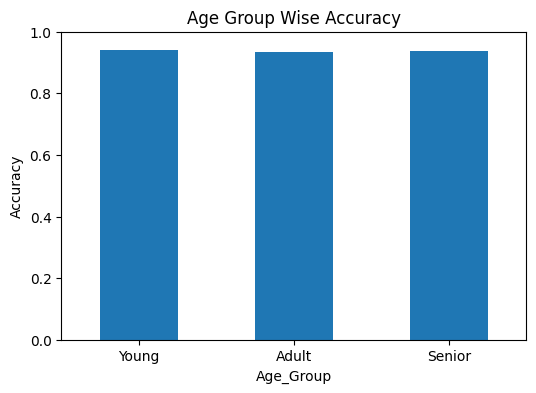

In [24]:
# ============================================
# 3.24 Age Group Bias Graph
# ============================================

age_accuracy.plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Age Group Wise Accuracy")

plt.ylabel("Accuracy")

plt.ylim(0,1)

plt.xticks(rotation=0)

plt.show()

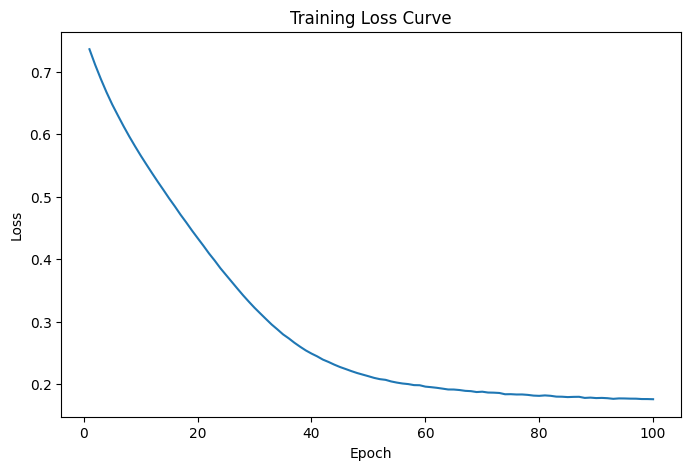

In [25]:
# ============================================
# 3.25 Training Loss Curve
# ============================================

plt.figure(figsize=(8,5))

plt.plot(
    range(1, epochs + 1),
    loss_history
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training Loss Curve")

plt.show()

In [26]:
# ============================================
# 3.26 Save Model
# ============================================

torch.save(

    model.state_dict(),

    "../models/depression_model.pth"
)

print("Model Saved Successfully")

Model Saved Successfully


In [27]:
# ============================================
# 3.27 Save Preprocessing Objects
# ============================================

os.makedirs(
    "../artifacts",
    exist_ok=True
)

# Save Scaler
joblib.dump(
    scaler,
    "../artifacts/scaler.pkl"
)

# Save Label Encoders
joblib.dump(
    label_encoders,
    "../artifacts/label_encoders.pkl"
)

# Save Imputers
joblib.dump(
    num_imputer,
    "../artifacts/num_imputer.pkl"
)

joblib.dump(
    cat_imputer,
    "../artifacts/cat_imputer.pkl"
)

print("Preprocessing Objects Saved Successfully")

Preprocessing Objects Saved Successfully


In [28]:
# ============================================
# 3.28 Final Message
# ============================================

print("Deep Learning Model Completed Successfully")

Deep Learning Model Completed Successfully
